In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

print(os.listdir('/content/drive/MyDrive'))

['IMG_20231101_221945.jpg', 'photo_2023-11-07_08-21-50.jpg', 'IMG_3090.png', 'IMG_3091.png', 'секция 1.gdoc', 'Портфолио.gsite', 'Профиль преподавателя.gsite', 'Презентация без названия.gslides', 'Шаблон анкеты.gform', 'Акт.gdoc', 'Новая таблица.gsheet', 'Дидар.gdoc', 'Новый документ.docx', 'Новый документ (1).gdoc', 'Копия Икт.gdoc', 'Икт.gdoc', 'Икт.docx', 'Өмірбаян.gdoc', 'Өмірбаян (1).docx', 'Новый шаблон презентации (4).gslides', 'Копия Новый шаблон презентации.pptx', 'Презентация икт.pptx', 'Презентация икт.gslides', 'Colab Notebooks', 'Новый документ.gdoc', 'Новый шаблон презентации (3).gslides', 'Новый шаблон презентации (2).gslides', 'Новый шаблон презентации (1).gslides', 'births.csv', '84221e78d533a8f0c2ff87b514cbe4752b96ba07ecc6db4fb1dad022aea4002b.pdf', 'Агылшын.gdoc', '1 р (1).gdoc', 'Р2 (1).gdoc', 'P3 (1).gdoc', 'P4 (1).gdoc', 'iLovePDF', 'Hw dif.gdoc', 'Dif 1 hw.gdoc', 'Копия Dif 1 hw.gdoc', 'сделай файл на англиском.gdoc', 'Sunnetulla Didar.gdoc', 'Sunnetulla

In [6]:
import os

print(os.listdir('/content/drive/MyDrive/archive'))

['Womens Clothing E-Commerce Reviews.csv']


In [9]:
import os

print(os.listdir('/content/drive/MyDrive/archive'))

['Womens Clothing E-Commerce Reviews.csv']


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import os
import re
import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка путей
# Если папка 'archive' лежит прямо на твоем Диске, путь будет именно таким:
PATH_TO_CSV = '/content/drive/MyDrive/archive/Womens Clothing E-Commerce Reviews.csv'

# Проверяем, видит ли Colab твой файл
if os.path.exists(PATH_TO_CSV):
    print("🎉 Ура! Файл успешно найден на Google Диске.")
else:
    print("❌ Ошибка: Файл не найден. Проверь, лежит ли папка 'archive' в корне твоего Google Диска.")

🎉 Ура! Файл успешно найден на Google Диске.


In [12]:
# 1. Загрузка датасета
df_raw = pd.read_csv(PATH_TO_CSV, index_col=0)

# 2. Удаляем пропуски в тексте отзывов
print(f"Исходное количество строк: {len(df_raw)}")
df = df_raw.dropna(subset=['Review Text']).copy()
print(f"Количество строк после удаления пустых отзывов: {len(df)}")

# 3. Разметка классов (Таргета) по оценкам (Rating)
# 1-2 звезды -> Негатив (0), 3 звезды -> Нейтральный (1), 4-5 звезд -> Позитив (2)
conditions = [
    (df['Rating'] <= 2),
    (df['Rating'] == 3),
    (df['Rating'] >= 4)
]
choices = [0, 1, 2]
df['Sentiment'] = np.select(conditions, choices, default=1)

# Текстовые метки для красивых графиков
sentiment_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
df['Sentiment_Label'] = df['Sentiment'].map(sentiment_map)

# Посмотрим на первые 3 строки
df[['Review Text', 'Rating', 'Sentiment_Label']].head(3)

Исходное количество строк: 23486
Количество строк после удаления пустых отзывов: 22641


,Review Text,Rating,Sentiment_Label
0,Absolutely wonderful - silky and sexy and comf...,4,Positive
1,Love this dress! it's sooo pretty. i happene...,5,Positive
2,I had such high hopes for this dress and reall...,3,Neutral


In [13]:
print("=== СТАТИСТИКА ДАТАСЕТА (НЕДЕЛЯ 1) ===")
print(f"Всего валидных текстовых образцов: {len(df)}")
print(f"Средний возраст покупателей: {df['Age'].mean():.2f} лет")
print("\nРаспределение отзывов по классам тональности:")
print(df['Sentiment_Label'].value_counts())
print("\nПроцентное соотношение классов:")
print(df['Sentiment_Label'].value_counts(normalize=True) * 100)

=== СТАТИСТИКА ДАТАСЕТА (НЕДЕЛЯ 1) ===
Всего валидных текстовых образцов: 22641
Средний возраст покупателей: 43.28 лет

Распределение отзывов по классам тональности:
Sentiment_Label
Positive    17448
Neutral      2823
Negative     2370
Name: count, dtype: int64

Процентное соотношение классов:
Sentiment_Label
Positive    77.063734
Neutral     12.468531
Negative    10.467736
Name: proportion, dtype: float64


/tmp/ipykernel_2267/3246510232.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Rating', palette='viridis', ax=ax[0])
/tmp/ipykernel_2267/3246510232.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment_Label', order=['Negative', 'Neutral', 'Positive'], palette='coolwarm', ax=ax[1])


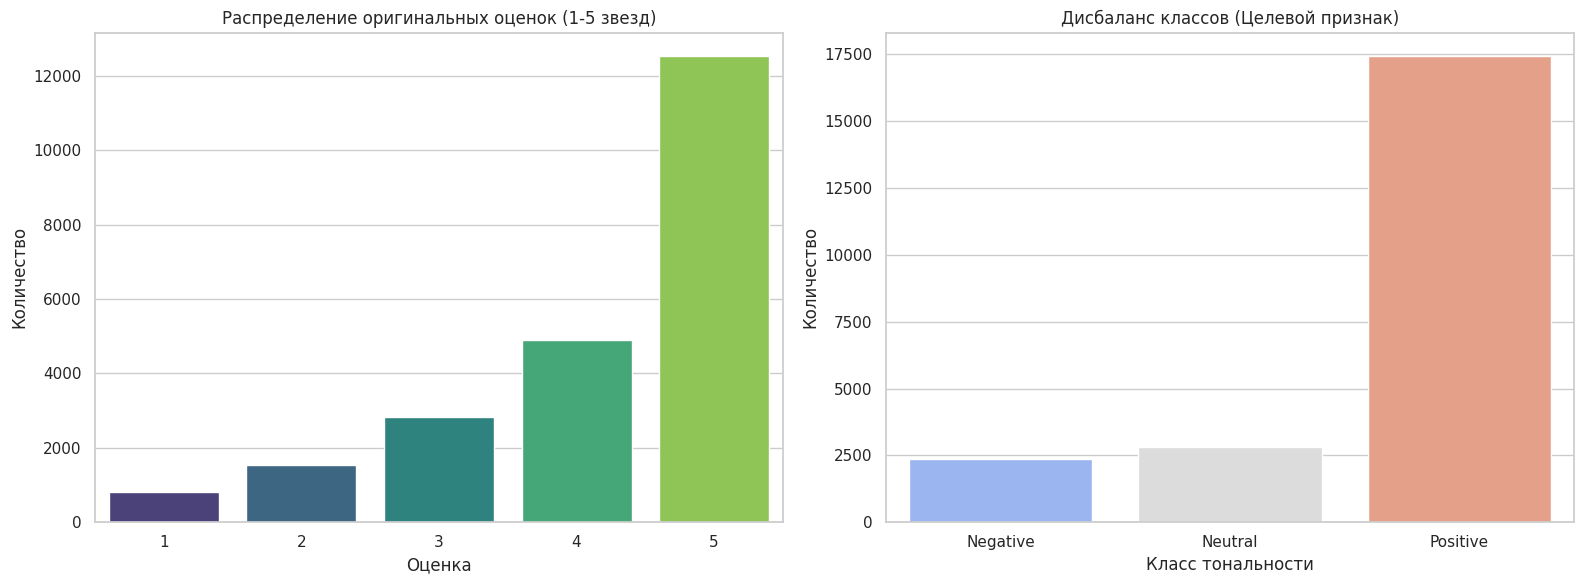

In [14]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# График распределения оригинальных оценок от 1 до 5
sns.countplot(data=df, x='Rating', palette='viridis', ax=ax[0])
ax[0].set_title('Распределение оригинальных оценок (1-5 звезд)')
ax[0].set_xlabel('Оценка')
ax[0].set_ylabel('Количество')

# График сгенерированных классов (Negative, Neutral, Positive)
sns.countplot(data=df, x='Sentiment_Label', order=['Negative', 'Neutral', 'Positive'], palette='coolwarm', ax=ax[1])
ax[1].set_title('Дисбаланс классов (Целевой признак)')
ax[1].set_xlabel('Класс тональности')
ax[1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

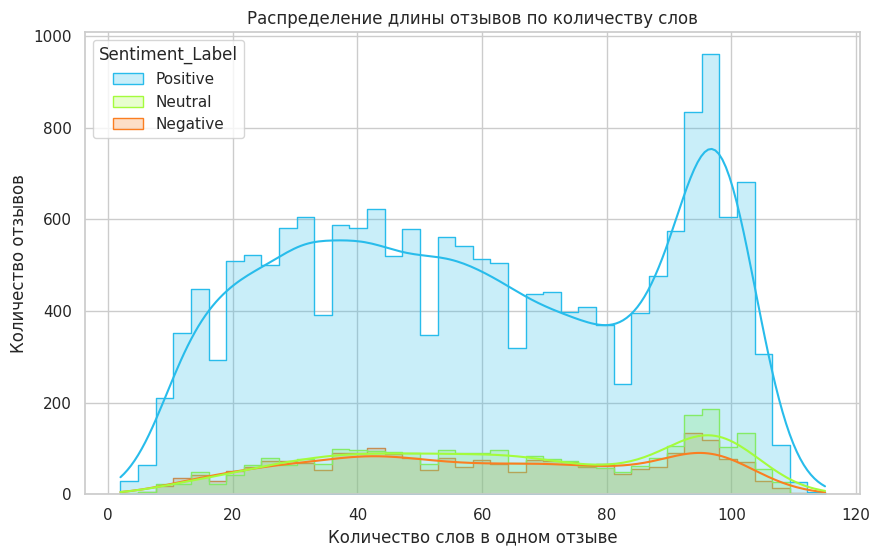

=== Анализ длины последовательностей ===
count    22641.000000
mean        60.196679
std         28.534612
min          2.000000
50%         59.000000
75%         88.000000
90%         98.000000
95%        101.000000
max        115.000000
Name: Word_Count, dtype: float64

💡 Вывод: 95% всех отзывов содержат меньше 115 слов. Значит, для будущих моделей LSTM/BERT оптимально выбрать длину паддинга (max_length) = 128.


In [15]:
# Считаем количество слов в каждом отзыве
df['Word_Count'] = df['Review Text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Word_Count', hue='Sentiment_Label', kde=True, bins=40, element='step', palette='turbo')
plt.title('Распределение длины отзывов по количеству слов')
plt.xlabel('Количество слов в одном отзыве')
plt.ylabel('Количество отзывов')
plt.show()

# Вывод точных квантилей длины
print("=== Анализ длины последовательностей ===")
print(df['Word_Count'].describe(percentiles=[0.5, 0.75, 0.90, 0.95]))
print("\n💡 Вывод: 95% всех отзывов содержат меньше 115 слов. "
      "Значит, для будущих моделей LSTM/BERT оптимально выбрать длину паддинга (max_length) = 128.")

/tmp/ipykernel_2267/738147545.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Sentiment_Label', y='Age', palette='Set2')


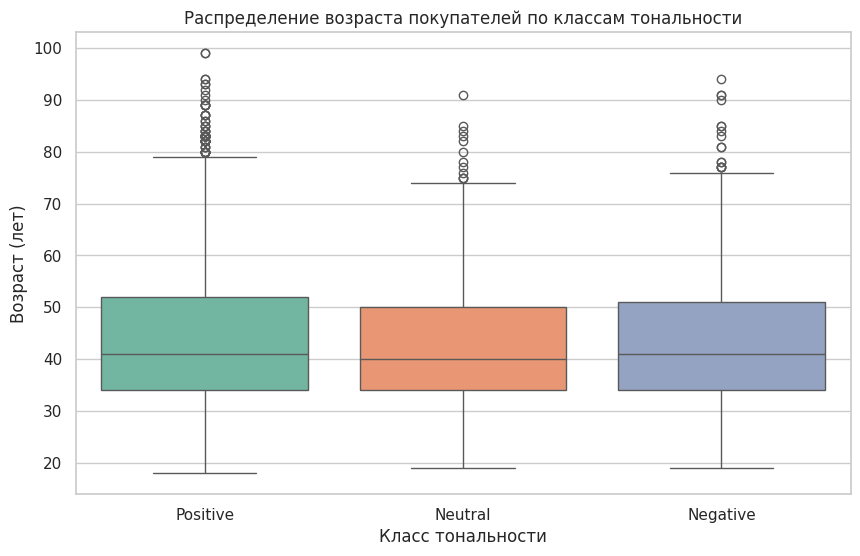

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Sentiment_Label', y='Age', palette='Set2')
plt.title('Распределение возраста покупателей по классам тональности')
plt.xlabel('Класс тональности')
plt.ylabel('Возраст (лет)')
plt.show()